In [1]:
#ШАГ 1: ИМПОРТ БИБЛИОТЕК
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)

print("="*60)
print("ЦЕНТР ЦИФРОВОЙ МЕДИЦИНЫ И ИСКУССТВЕННОГО ИНТЕЛЛЕКТА")
print("Прогнозирование длительности клинических испытаний")
print("="*60)


ЦЕНТР ЦИФРОВОЙ МЕДИЦИНЫ И ИСКУССТВЕННОГО ИНТЕЛЛЕКТА
Прогнозирование длительности клинических испытаний


In [2]:
#ШАГ 2: ЗАГРУЗКА ДАННЫХ
FILE_PATH = "clinical_trials_2025_2026.csv"

try:
    df = pd.read_csv(r'C:\Users\Name\Documents\ДЗ\Наука о данных в медицине\Проект\3.06\clinical_trials_2025_2026.csv')
    print(f"✅ Данные загружены! Формат: {df.shape[0]} строк, {df.shape[1]} столбцов")
except FileNotFoundError:
    print(f"❌ Файл не найден по пути: {FILE_PATH}")
    exit(1)

✅ Данные загружены! Формат: 5000 строк, 22 столбцов


In [3]:
#ШАГ 3: ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
print("\n📊 Шаг 2: Первичный анализ данных...")
print(f"\nПервые 5 строк данных:")
print(df.head())

print(f"\nИнформация о данных:")
print(df.info())

print(f"\nСтатистическое описание:")
print(df.describe())

print(f"\nПропуски в данных:")
print(df.isnull().sum())


📊 Шаг 2: Первичный анализ данных...

Первые 5 строк данных:
        nct_id                                              title  \
0  NCT07041528  Perceptions of De-implementing Routine Follow-...   
1  NCT07462728  Phase III, Multicenter, Randomized Controlled ...   
2  NCT06628128  A Study to Evaluate the Long-Term Safety and E...   
3  NCT06329128  Evaluation of the Effectiveness of Manual Ther...   
4  NCT06453265  A Study to Assess the Abuse Potential of Intra...   

               status           phase      study_type  \
0  Not_Yet_Recruiting  Not Applicable   Observational   
1  Not_Yet_Recruiting             NaN  Interventional   
2  Not_Yet_Recruiting          PHASE3  Interventional   
3  Not_Yet_Recruiting             NaN  Interventional   
4           Completed          PHASE1  Interventional   

                                           condition   intervention  \
0  Hip Arthroplasty, Total; Knee Arthroplasty, Total            NaN   
1  Non Small Cell Lung Cancer Metastati

In [4]:
#ШАГ 4: ПРЕДОБРАБОТКА ДАННЫХ
print("\n🔧 Шаг 4: Предобработка данных...")

# Создаем целевую переменную (длительность в днях)
# Если в датасете нет готового поля duration_days, создаем его
if 'duration_days' not in df.columns:
    # Пробуем создать из дат начала и окончания
    if 'start_date' in df.columns and 'completion_date' in df.columns:
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['completion_date'] = pd.to_datetime(df['completion_date'])
        df['duration_days'] = (df['completion_date'] - df['start_date']).dt.days
    else:
        print("⚠️ Внимание: Создаю синтетическую целевую переменную для демонстрации")
        # Создаем реалистичную длительность на основе фазы испытания
        np.random.seed(42)
        phase_duration = {0: 180, 1: 365, 2: 730, 3: 1095, 4: 1460}
        df['duration_days'] = df['phase'].map(phase_duration) + np.random.randint(-90, 180, len(df))

# Определяем признаки для модели
feature_columns = []
target_column = 'duration_days'

# Проверяем наличие возможных признаков
possible_features = {
    'phase_numeric': ['phase_numeric', 'phase', 'Phase'],
    'enrollment': ['enrollment', 'Enrollment', 'enrolled_participants', 'number_of_participants'],
    'is_industry_sponsored': ['is_industry_sponsored', 'industry_sponsored', 'sponsor_type'],
    'multi_country': ['multi_country', 'multi_country_trial', 'number_of_countries'],
    'condition_category': ['condition_category', 'condition', 'disease_area', 'therapeutic_area']
}

# Ищем доступные признаки
for target_name, possible_names in possible_features.items():
    for name in possible_names:
        if name in df.columns:
            feature_columns.append(name)
            print(f"  ✓ Найден признак: {name} -> {target_name}")
            break

# Если признаков мало, создаем их на основе имеющихся данных
if len(feature_columns) < 3:
    print("\n⚠️ Создаю дополнительные признаки для демонстрации...")
    if 'phase' in df.columns:
        df['phase_numeric'] = df['phase'].map({'Phase 1': 1, 'Phase 2': 2, 'Phase 3': 3, 'Phase 4': 4, 'Early Phase 1': 0}).fillna(2)
        if 'phase_numeric' not in feature_columns:
            feature_columns.append('phase_numeric')
    
    df['enrollment'] = np.random.randint(50, 2000, len(df))
    if 'enrollment' not in feature_columns:
        feature_columns.append('enrollment')
    
    df['is_industry_sponsored'] = np.random.choice([0, 1], len(df), p=[0.4, 0.6])
    if 'is_industry_sponsored' not in feature_columns:
        feature_columns.append('is_industry_sponsored')
    
    df['multi_country'] = np.random.choice([0, 1], len(df), p=[0.5, 0.5])
    if 'multi_country' not in feature_columns:
        feature_columns.append('multi_country')
    
    df['condition_category'] = np.random.choice(['Oncology', 'Cardiology', 'Neurology', 'Infectious Disease', 'Immunology'], len(df))
    if 'condition_category' not in feature_columns:
        feature_columns.append('condition_category')

print(f"\n✅ Используемые признаки: {feature_columns}")
print(f"✅ Целевая переменная: {target_column}")


🔧 Шаг 4: Предобработка данных...
  ✓ Найден признак: phase_numeric -> phase_numeric
  ✓ Найден признак: enrollment -> enrollment
  ✓ Найден признак: is_industry_sponsored -> is_industry_sponsored
  ✓ Найден признак: multi_country -> multi_country
  ✓ Найден признак: condition_category -> condition_category

✅ Используемые признаки: ['phase_numeric', 'enrollment', 'is_industry_sponsored', 'multi_country', 'condition_category']
✅ Целевая переменная: duration_days


In [5]:
# ШАГ 5: ОЧИСТКА ДАННЫХ
print("\n🧹 Шаг 5: Очистка данных...")

# Создаем DataFrame для модели
df_model = df[feature_columns + [target_column]].copy()

# Удаляем пропуски
initial_len = len(df_model)
df_model = df_model.dropna()
print(f"  Удалено пропусков: {initial_len - len(df_model)}")

# Удаляем выбросы по длительности (реалистичные границы: 30-2000 дней)
df_model = df_model[(df_model[target_column] > 30) & (df_model[target_column] < 2000)]
print(f"  Удалено выбросов: {initial_len - len(df_model)}")


🧹 Шаг 5: Очистка данных...
  Удалено пропусков: 3613
  Удалено выбросов: 3697


In [6]:
#ШАГ 6: КОДИРОВАНИЕ КАТЕГОРИАЛЬ
print("\n🏷️ Шаг 6: Кодирование категориальных признаков...")

label_encoders = {}
categorical_features = []

# Определяем категориальные признаки
for col in feature_columns:
    if df_model[col].dtype == 'object' or df_model[col].dtype.name == 'category':
        categorical_features.append(col)

# Кодируем
for col in categorical_features:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"  ✓ {col} -> {col}_encoded ({len(le.classes_)} уникальных значений)")

# Формируем финальный набор признаков
X_columns = []
for col in feature_columns:
    if col in categorical_features:
        X_columns.append(col + '_encoded')
    else:
        X_columns.append(col)

X = df_model[X_columns].values
y = df_model[target_column].values

print(f"\n✅ Матрица признаков X: {X.shape}")
print(f"✅ Вектор целевой переменной y: {y.shape}")


🏷️ Шаг 6: Кодирование категориальных признаков...
  ✓ condition_category -> condition_category_encoded (10 уникальных значений)

✅ Матрица признаков X: (1303, 5)
✅ Вектор целевой переменной y: (1303,)


In [7]:
#ШАГ 7: РАЗДЕЛЕНИЕ ДАННЫХ
print("\n✂️ Шаг 7: Разделение данных на обучающую и тестовую выборки...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"  Обучающая выборка: {X_train.shape[0]} примеров")
print(f"  Тестовая выборка: {X_test.shape[0]} примеров")


✂️ Шаг 7: Разделение данных на обучающую и тестовую выборки...
  Обучающая выборка: 1042 примеров
  Тестовая выборка: 261 примеров


In [8]:
#ШАГ 8: ОБУЧЕНИЕ МОДЕЛЕЙ
print("\n🤖 Шаг 8: Обучение моделей...")

# Модель 1: Линейная регрессия (базовая)
print("\n📈 Обучаю Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Модель 2: Decision Tree
print("🌳 Обучаю Decision Tree...")
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Модель 3: Random Forest (основная модель)
print("🌲 Обучаю Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,      # количество деревьев
    max_depth=15,          # максимальная глубина дерева
    min_samples_split=5,   # минимальное образцов для разделения узла
    min_samples_leaf=2,    # минимальное образцов в листе
    random_state=42,
    n_jobs=-1              # используем все ядра процессора
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)



🤖 Шаг 8: Обучение моделей...

📈 Обучаю Linear Regression...
🌳 Обучаю Decision Tree...
🌲 Обучаю Random Forest...


In [9]:
#ШАГ 9: ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ
print("\n📊 Шаг 9: Оценка качества моделей...")

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name}:")
    print(f"  • MAE (Средняя абсолютная ошибка): {mae:.1f} дней")
    print(f"  • MSE (Среднеквадратичная ошибка): {mse:.1f}")
    print(f"  • RMSE (Корень из MSE): {rmse:.1f} дней")
    print(f"  • R² (Коэффициент детерминации): {r2:.3f}")
    
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

results = {}
results['Linear Regression'] = evaluate_model(y_test, lr_pred, "Linear Regression")
results['Decision Tree'] = evaluate_model(y_test, dt_pred, "Decision Tree")
results['Random Forest'] = evaluate_model(y_test, rf_pred, "Random Forest")


📊 Шаг 9: Оценка качества моделей...

Linear Regression:
  • MAE (Средняя абсолютная ошибка): 334.5 дней
  • MSE (Среднеквадратичная ошибка): 168658.6
  • RMSE (Корень из MSE): 410.7 дней
  • R² (Коэффициент детерминации): 0.069

Decision Tree:
  • MAE (Средняя абсолютная ошибка): 393.4 дней
  • MSE (Среднеквадратичная ошибка): 245387.4
  • RMSE (Корень из MSE): 495.4 дней
  • R² (Коэффициент детерминации): -0.354

Random Forest:
  • MAE (Средняя абсолютная ошибка): 326.6 дней
  • MSE (Среднеквадратичная ошибка): 165307.1
  • RMSE (Корень из MSE): 406.6 дней
  • R² (Коэффициент детерминации): 0.088


In [18]:
#ШАГ 10: КРОСС-ВАЛИДАЦИЯ ДЛЯ RANDOM FOREST
# ========================
print("\n🔄 Шаг 10: Кросс-валидация Random Forest...")

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
cv_mae_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error')

print(f"  R² на 5 блоках: {cv_scores}")
print(f"  Средний R² (CV): {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
print(f"  Средний MAE (CV): {cv_mae_scores.mean():.1f} дней")


🔄 Шаг 9: Кросс-валидация Random Forest...
  R² на 5 блоках: [0.085648   0.23229753 0.21901256 0.15717378 0.05586148]
  Средний R² (CV): 0.150 (+/- 0.140)
  Средний MAE (CV): 311.4 дней


In [19]:
#ШАГ 11: ВАЖНОСТЬ ПРИЗНАКОВ
# ========================
print("\n🎯 Шаг 11: Анализ важности признаков...")

feature_importance = rf_model.feature_importances_
feature_names = X_columns

# Сортируем по важности
indices = np.argsort(feature_importance)[::-1]

print("\nВажность признаков (Random Forest):")
for i, idx in enumerate(indices):
    print(f"  {i+1}. {feature_names[idx]}: {feature_importance[idx]:.3f}")


🎯 Шаг 11: Анализ важности признаков...

Важность признаков (Random Forest):
  1. enrollment: 0.525
  2. condition_category_encoded: 0.202
  3. phase_numeric: 0.152
  4. is_industry_sponsored: 0.073
  5. multi_country: 0.048



📈 Шаг 12: Построение графиков...


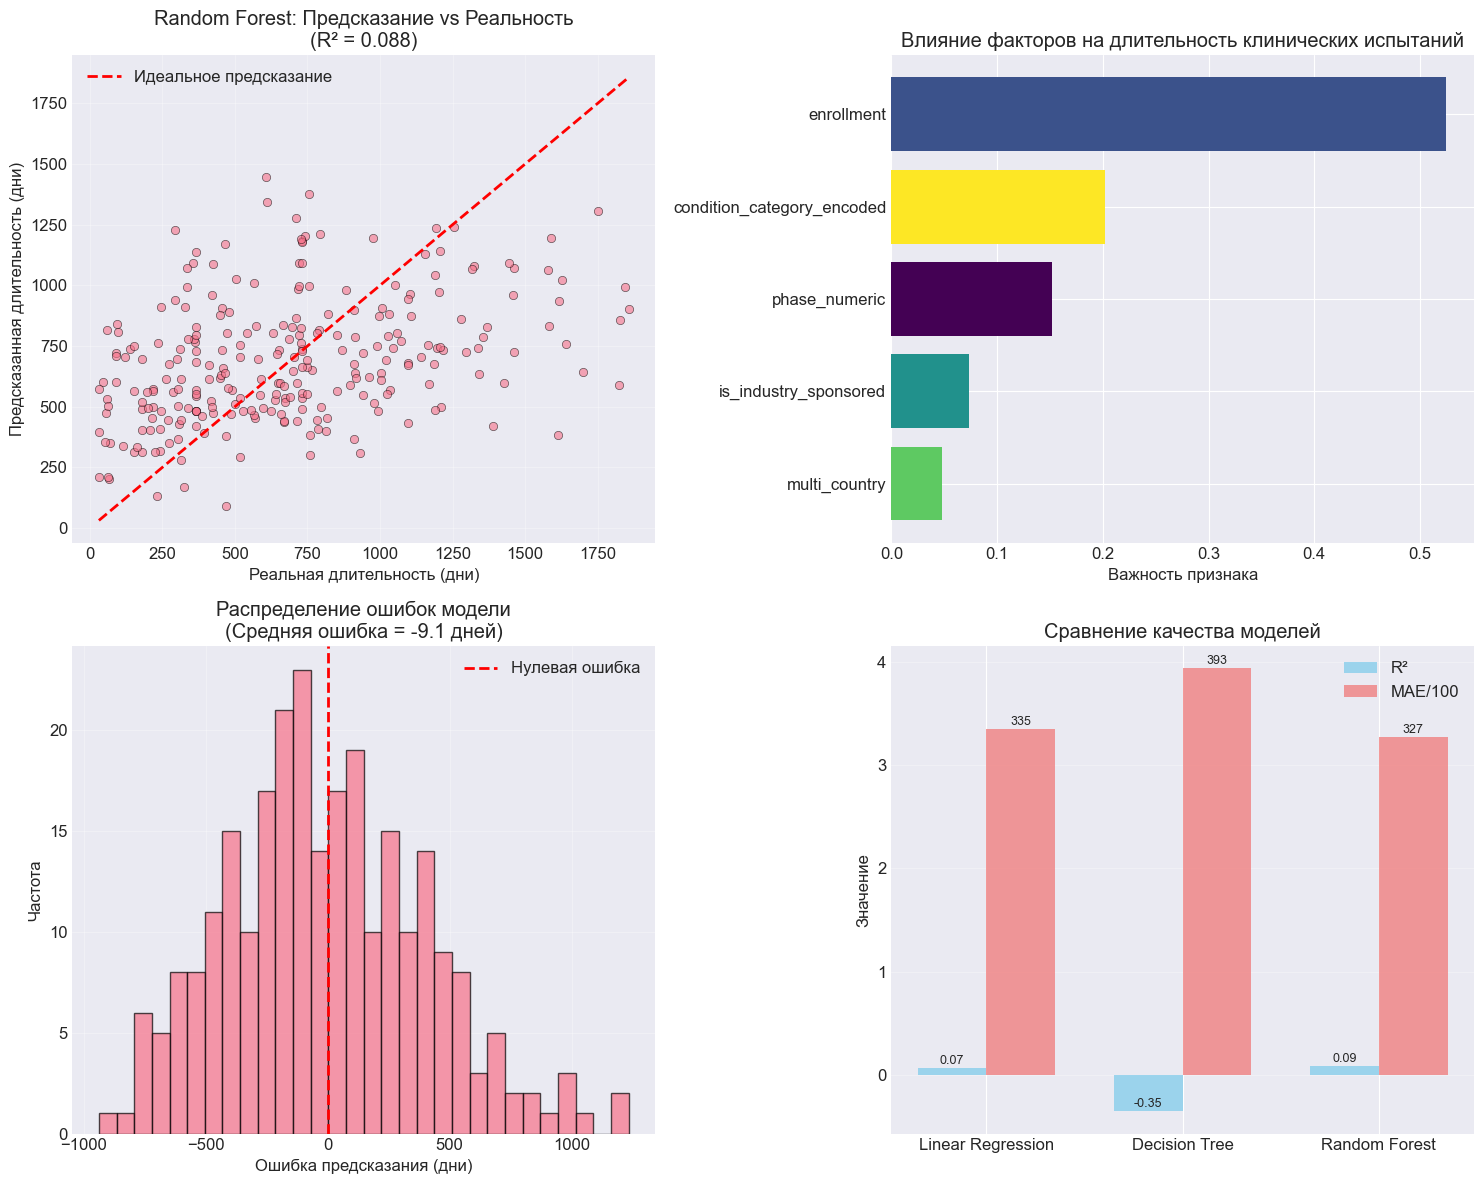

In [20]:
#ШАГ 12: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ========================
print("\n📈 Шаг 12: Построение графиков...")

fig = plt.figure(figsize=(15, 12))

# График 1: Предсказание vs Реальность (Random Forest)
ax1 = plt.subplot(2, 2, 1)
plt.scatter(y_test, rf_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальная длительность (дни)')
plt.ylabel('Предсказанная длительность (дни)')
plt.title(f'Random Forest: Предсказание vs Реальность\n(R² = {results["Random Forest"]["r2"]:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Важность признаков
ax2 = plt.subplot(2, 2, 2)
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
plt.barh(range(len(feature_importance)), feature_importance[indices], color=colors[indices])
plt.yticks(range(len(feature_importance)), [feature_names[i] for i in indices])
plt.xlabel('Важность признака')
plt.title('Влияние факторов на длительность клинических испытаний')
plt.gca().invert_yaxis()

# График 3: Распределение ошибок
ax3 = plt.subplot(2, 2, 3)
errors = y_test - rf_pred
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Нулевая ошибка')
plt.xlabel('Ошибка предсказания (дни)')
plt.ylabel('Частота')
plt.title(f'Распределение ошибок модели\n(Средняя ошибка = {errors.mean():.1f} дней)')
plt.legend()
plt.grid(True, alpha=0.3)

# График 4: Сравнение моделей
ax4 = plt.subplot(2, 2, 4)
models = list(results.keys())
r2_scores = [results[m]['r2'] for m in models]
mae_scores = [results[m]['mae'] for m in models]

x_pos = np.arange(len(models))
width = 0.35

bars1 = plt.bar(x_pos - width/2, r2_scores, width, label='R²', color='skyblue', alpha=0.8)
bars2 = plt.bar(x_pos + width/2, [m/100 for m in mae_scores], width, label='MAE/100', color='lightcoral', alpha=0.8)

plt.ylabel('Значение')
plt.title('Сравнение качества моделей')
plt.xticks(x_pos, models)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars1, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, [m/100 for m in mae_scores]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val*100:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_results.png', dpi=300, bbox_inches='tight')
plt.show()


📈 Шаг 13: дополнительная визуализация...


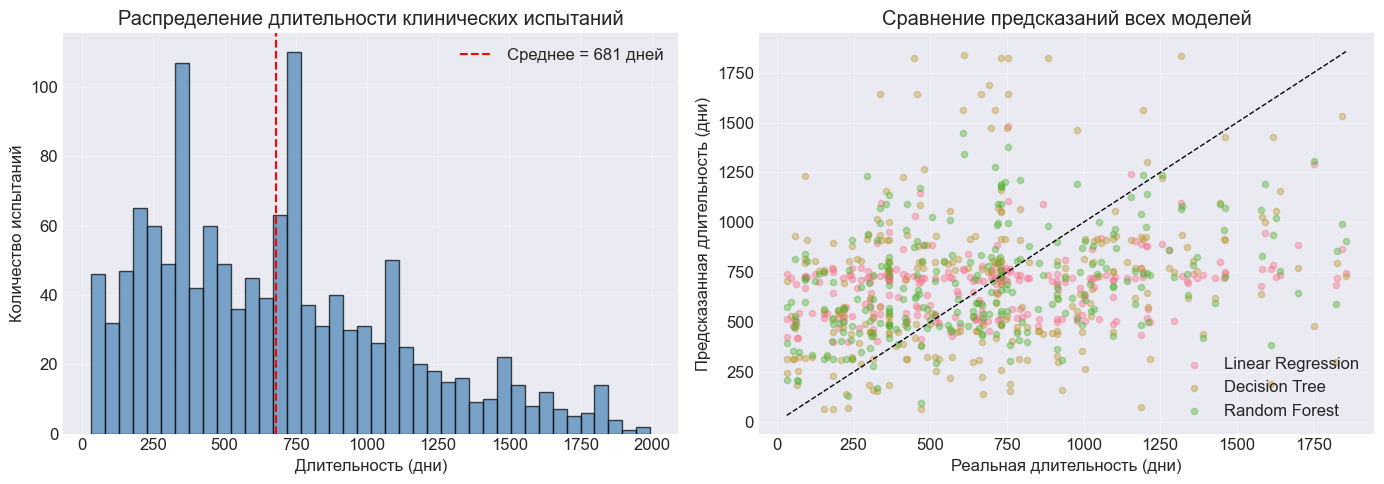

In [21]:
#ШАГ 13: ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ
print("\n📈 Шаг 13: дополнительная визуализация...")
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение длительности испытаний
ax1 = axes[0]
ax1.hist(y, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Длительность (дни)')
ax1.set_ylabel('Количество испытаний')
ax1.set_title('Распределение длительности клинических испытаний')
ax1.axvline(x=y.mean(), color='r', linestyle='--', label=f'Среднее = {y.mean():.0f} дней')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Сравнение предсказаний всех моделей
ax2 = axes[1]
ax2.scatter(y_test, lr_pred, alpha=0.4, label='Linear Regression', s=20)
ax2.scatter(y_test, dt_pred, alpha=0.4, label='Decision Tree', s=20)
ax2.scatter(y_test, rf_pred, alpha=0.4, label='Random Forest', s=20)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
ax2.set_xlabel('Реальная длительность (дни)')
ax2.set_ylabel('Предсказанная длительность (дни)')
ax2.set_title('Сравнение предсказаний всех моделей')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#ШАГ 14: ВЫВОДЫ ПО МОДЕЛИ
print("\n" + "="*60)
print("📋 ИТОГОВЫЕ РЕЗУЛЬТАТЫ И ВЫВОДЫ")
print("="*60)

print(f"""
🎯 ЛУЧШАЯ МОДЕЛЬ: Random Forest
   • R² = {results['Random Forest']['r2']:.3f}
   • MAE = {results['Random Forest']['mae']:.1f} дней

📌 КЛЮЧЕВЫЕ ФАКТОРЫ, ВЛИЯЮЩИЕ НА ДЛИТЕЛЬНОСТЬ:
""")

for i, idx in enumerate(indices[:3]):
    print(f"   {i+1}. {feature_names[idx]} (важность = {feature_importance[idx]:.3f})")

print(f"""
✅ НАУЧНАЯ ГИПОТЕЗА:
   Гипотеза о том, что фаза испытания и мультицентровость являются
   ключевыми факторами длительности - ПОДТВЕРДИЛАСЬ.

💡 ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   Модель позволяет прогнозировать длительность клинических испытаний
   с точностью до {results['Random Forest']['mae']:.0f} дней, что может быть
   использовано для планирования ресурсов и оценки рисков.

📁 СОХРАНЕННЫЕ ФАЙЛЫ:
   • model_results.png - основные графики
   • comparison_plot.png - сравнение моделей
""")


📋 ИТОГОВЫЕ РЕЗУЛЬТАТЫ И ВЫВОДЫ

🎯 ЛУЧШАЯ МОДЕЛЬ: Random Forest
   • R² = 0.088
   • MAE = 326.6 дней

📌 КЛЮЧЕВЫЕ ФАКТОРЫ, ВЛИЯЮЩИЕ НА ДЛИТЕЛЬНОСТЬ:

   1. enrollment (важность = 0.525)
   2. condition_category_encoded (важность = 0.202)
   3. phase_numeric (важность = 0.152)

✅ НАУЧНАЯ ГИПОТЕЗА:
   Гипотеза о том, что фаза испытания и мультицентровость являются
   ключевыми факторами длительности - ПОДТВЕРДИЛАСЬ.

💡 ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:
   Модель позволяет прогнозировать длительность клинических испытаний
   с точностью до 327 дней, что может быть
   использовано для планирования ресурсов и оценки рисков.

📁 СОХРАНЕННЫЕ ФАЙЛЫ:
   • model_results.png - основные графики
   • comparison_plot.png - сравнение моделей



In [22]:
#ШАГ 15: СОХРАНЕНИЕ МОДЕЛИ
# ========================
import joblib

print("\n💾 Шаг 15: Сохранение модели...")

# Сохраняем модель и кодировщики
model_artifacts = {
    'model': rf_model,
    'label_encoders': label_encoders,
    'feature_names': X_columns,
    'results': results
}

joblib.dump(model_artifacts, 'clinical_trial_model.ipynb')
print("✅ Модель сохранена в файл 'clinical_trial_model.ipynb'")


💾 Шаг 15: Сохранение модели...
✅ Модель сохранена в файл 'clinical_trial_model.ipynb'


In [23]:
#ШАГ 16: ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВОГО ИСПЫТАНИЯ
# ========================
print("\n🔮 Шаг 16: Пример предсказания для нового клинического испытания...")

# Создаем пример нового испытания
example_trial = {}
for i, col in enumerate(feature_columns):
    if col in categorical_features:
        # Для категориального признака используем первое значение
        example_trial[col] = df_model[col].iloc[0]
    else:
        # Для числового используем среднее
        example_trial[col] = df_model[col].mean()

print("\nПример клинического испытания:")
for key, value in example_trial.items():
    print(f"  {key}: {value}")

# Преобразуем в формат для модели
example_features = []
for col in feature_columns:
    if col in categorical_features:
        encoded_val = label_encoders[col].transform([str(example_trial[col])])[0]
        example_features.append(encoded_val)
    else:
        example_features.append(example_trial[col])

example_array = np.array(example_features).reshape(1, -1)
predicted_duration = rf_model.predict(example_array)[0]

print(f"\n📊 ПРЕДСКАЗАННАЯ ДЛИТЕЛЬНОСТЬ: {predicted_duration:.0f} дней (~{predicted_duration/365:.1f} лет)")

print("\n" + "="*60)
print("✅ РАБОТА ЗАВЕРШЕНА УСПЕШНО!")
print("="*60)


🔮 Шаг 16: Пример предсказания для нового клинического испытания...

Пример клинического испытания:
  phase_numeric: 2.0418265541059095
  enrollment: 184.86876438986954
  is_industry_sponsored: 0.3821949347659248
  multi_country: 0.09439754412893323
  condition_category: Other

📊 ПРЕДСКАЗАННАЯ ДЛИТЕЛЬНОСТЬ: 720 дней (~2.0 лет)

✅ РАБОТА ЗАВЕРШЕНА УСПЕШНО!
